# Pandas Practice 2

![IRIS, https://github.com/simonava5/fishers-iris-data](./images/iris.png)

After the notebook with a lot of new input, let's start applying it totally by yourselves. 
For this purpose we will use one of the most standard real-life datasets: Its called Iris Dataset, and is all about the plant iris. Let's learn a little bit more about the dataset by looking at it. 

## Learning Objectives





By the end of this notebook, you will feel more comfortable with your newly acquired knowledge, as you will see that you can

- load data from csv files into DataFrames
- access data stored in DataFrames
- use the general functions of a DataFrame to answer questions about the data
- create insightful plots using the pandas function `.plot()`
- explain what conclusions you draw from these visualizations.


In [1]:
# import pandas
import pandas as pd

In [2]:
# load the data
df = pd.read_csv('data/iris.csv')

Let us first have a look at the head of the table, maybe also on the last 10 rows...

In [7]:
df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [6]:
df.tail(10)

,sepal_length,sepal_width,petal_length,petal_width,species
140,6.7,3.1,5.6,2.4,Iris-virginica
141,6.9,3.1,5.1,2.3,Iris-virginica
142,5.8,2.7,5.1,1.9,Iris-virginica
143,6.8,3.2,5.9,2.3,Iris-virginica
144,6.7,3.3,5.7,2.5,Iris-virginica
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


How many irises are in the data set?

In [16]:
df['species'].count()

np.int64(150)

How many different species are there?

In [17]:
len(df.groupby(by='species').agg('count'))

3

Calculate the mean, median, mode for petal length

In [27]:
df['petal_length'].apply(['mean', 'median'])

mean      3.758667
median    4.350000
Name: petal_length, dtype: float64

In [30]:
df['petal_length'].mode()[0]

np.float64(1.5)

What can you conclude about the distribution for petal length?

mean < median

What is the smallest and largest value for petal length?

In [31]:
df['petal_length'].apply(['min', 'max'])

min    1.0
max    6.9
Name: petal_length, dtype: float64

Calculate the variance and standard deviation for petal length

In [32]:
df['petal_length'].apply(['var', 'std'])

var    3.113179
std    1.764420
Name: petal_length, dtype: float64

Calculate the basic descriptive statistics for all columns of the iris data set with a single command.

In [33]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


What is the overall average for sepal length?

In [34]:
df['sepal_length'].mean()

np.float64(5.843333333333334)

Use the DataFrame grouping function to determine the count by species.

In [36]:
df.groupby(by='species').agg('count')

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,50,50,50,50
Iris-versicolor,50,50,50,50
Iris-virginica,50,50,50,50


Use the DataFrame grouping function to determine the average length and width of sepals and pedals by species.

In [40]:
df.groupby(by='species').agg('mean')

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


Add the sum of the sepal width and length as a new column to your DataFrame.

In [41]:
df['sepal'] = df['sepal_width'] + df['sepal_length']

Visualize petal length with a histogram

<Axes: >

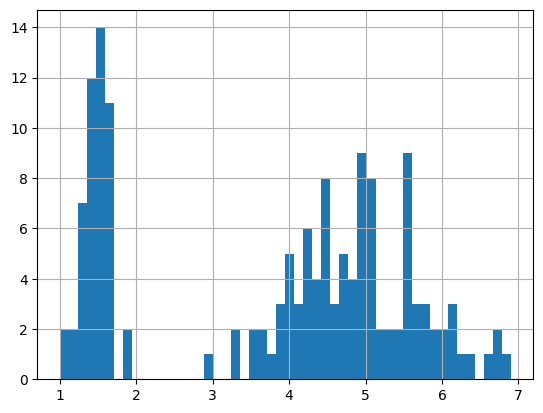

In [43]:
df['petal_length'].hist(bins=50)

species
Iris-setosa        Axes(0.125,0.11;0.775x0.77)
Iris-versicolor    Axes(0.125,0.11;0.775x0.77)
Iris-virginica     Axes(0.125,0.11;0.775x0.77)
Name: petal_length, dtype: object

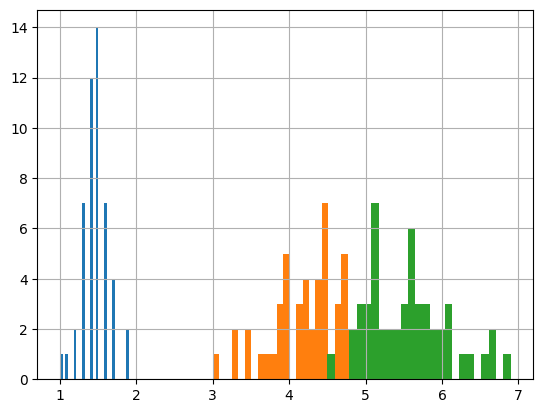

In [46]:
df.groupby('species')['petal_length'].hist(bins=25)

Describe the distribution

It seems to be there are two species, that are separate from each other by petal length. 

Which is more informative: the summary statistics or visualizations?

In [ ]:
Visualization

Visualize petal length and width with a "scatter_matrix"

<Axes: xlabel='petal_length', ylabel='petal_width'>

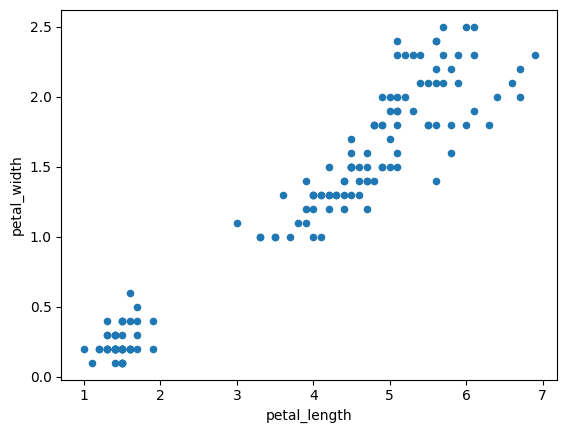

In [47]:
df.plot(x='petal_length', y='petal_width', kind='scatter')

In [51]:
import seaborn as sns

<Axes: xlabel='petal_length', ylabel='petal_width'>

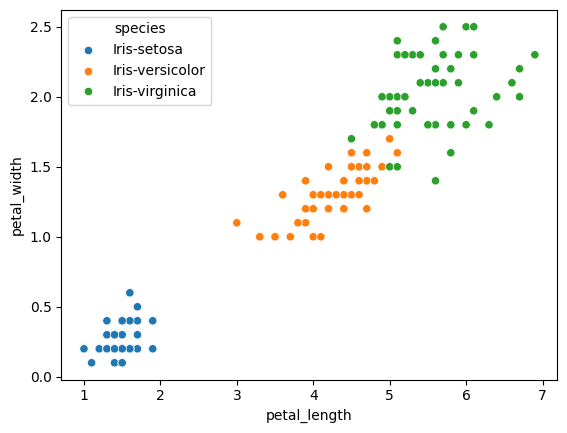

In [53]:
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species')

Create a new column with a rough estimate of petal area by multiplying petal length and width together.

In [54]:
df['petal_area'] = df['petal_length'] * df['petal_width']

Create a new DataFrame with petal areas greater than $1cm^2$.

In [55]:
df2 = df[df['petal_area']>1].copy()

<Axes: >

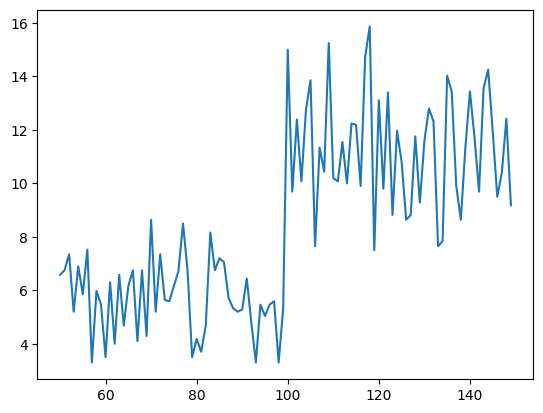

In [57]:
df2['petal_area'].plot()

Create 3 new DataFrames, one for each species. Use the entire dataset.

In [58]:
df['species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [64]:
dct = {}
for i in df['species'].unique():
    dct[i] = df[df['species'] == i].copy()

In [67]:
len(dct)

3

In [68]:
dct.keys()

dict_keys(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'])